In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

c:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Kimo Store\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


In [3]:
import os
import pandas as pd

# List the files to see what's inside the downloaded folder
print(os.listdir(path))

['heart.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "heart.csv"))
print(df.head(10))
#chi2

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.shape

(918, 12)

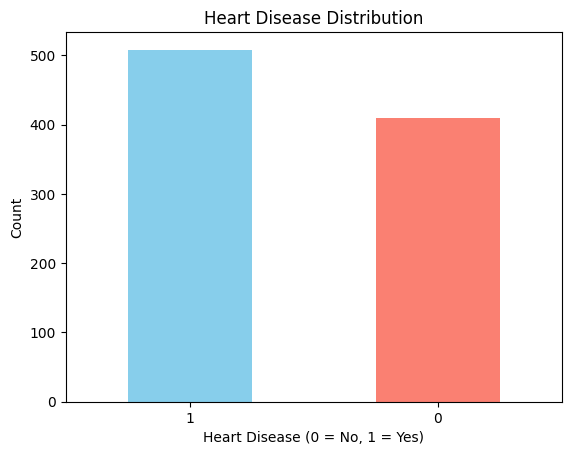

In [7]:
df['HeartDisease'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

,feature,chi2_stat,p_value
13,ST_Slope_Up,202.447182,6.106858e-46
12,ST_Slope_Flat,140.635329,1.933233e-32
10,ExerciseAngina_Y,133.640134,6.549289e-31
3,ChestPainType_ATA,120.349494,5.304212e-28
2,ChestPainType_ASY,112.672269,2.545580e-26
9,ExerciseAngina_N,90.640749,1.722756e-21
0,Sex_F,67.640033,1.962423e-16
4,ChestPainType_NAP,32.427756,1.237068e-08
1,Sex_M,18.006243,2.201817e-05
11,ST_Slope_Down,12.835932,3.400260e-04


C:\Users\Kimo Store\AppData\Local\Temp\ipykernel_14040\3154383157.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="chi2_stat", y="feature", data=chi2_results, palette="viridis")


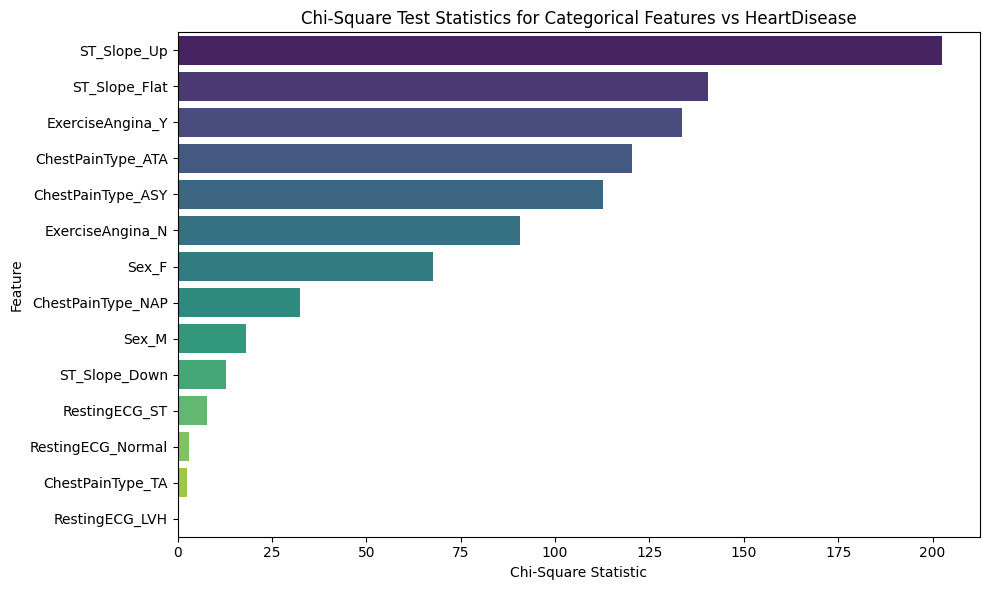

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import chi2

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'HeartDisease' in categorical_features:
    categorical_features.remove('HeartDisease')

# One-hot encode
df_encoded = pd.get_dummies(df[categorical_features])

# Chi2 test
chi2_stats, p_values = chi2(df_encoded, df['HeartDisease'])

chi2_results = pd.DataFrame({
    'feature': df_encoded.columns,
    'chi2_stat': chi2_stats,
    'p_value': p_values
}).sort_values(by='p_value')

display(chi2_results)

# --- Plot chi2 scores ---
plt.figure(figsize=(10, 6))
sns.barplot(x="chi2_stat", y="feature", data=chi2_results, palette="viridis")
plt.title("Chi-Square Test Statistics for Categorical Features vs HeartDisease")
plt.xlabel("Chi-Square Statistic")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()




HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


C:\Users\Kimo Store\AppData\Local\Temp\ipykernel_14040\4150450249.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.values, y=correlation.index, palette="coolwarm")


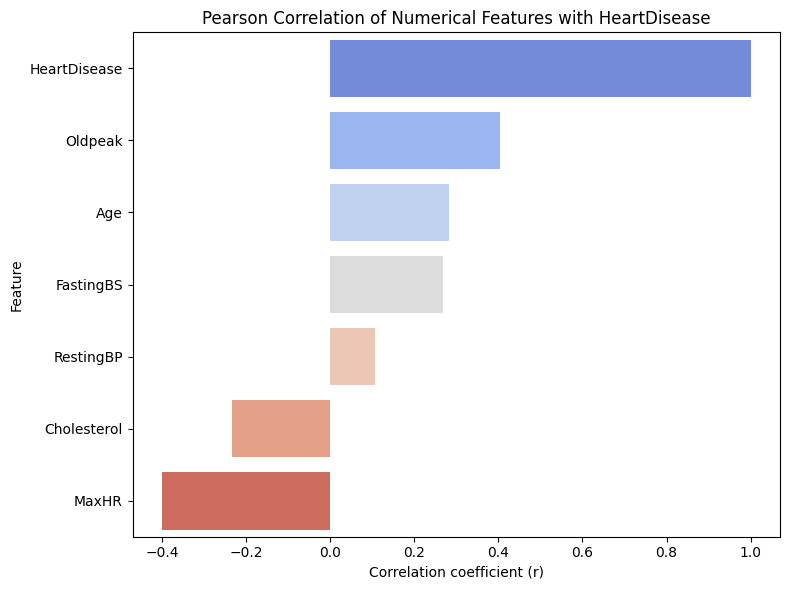

In [9]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- Collect numerical features ---
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target if it's numerical (e.g., HeartDisease is 0/1)
if "HeartDisease" in numerical_features:
    numerical_features.remove("HeartDisease")

# --- Scale with MinMaxScaler ---
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_features]),
                         columns=numerical_features)

# Add target back for correlation
df_scaled["HeartDisease"] = df["HeartDisease"].values

# --- Pearson correlation ---
correlation = df_scaled.corr(method="pearson")["HeartDisease"].sort_values(ascending=False)

print(correlation)

# --- Plot correlations ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(x=correlation.values, y=correlation.index, palette="coolwarm")
plt.title("Pearson Correlation of Numerical Features with HeartDisease")
plt.xlabel("Correlation coefficient (r)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [10]:
num_features = ["Oldpeak", "Age", "FastingBS", "RestingBP", "Cholesterol"]
scaler = MinMaxScaler()
X_num = pd.DataFrame(scaler.fit_transform(df[num_features]), columns=num_features)

cat_features = [
    "ST_Slope_Up",
    "ST_Slope_Flat",
    "ExerciseAngina_Y",
    "ChestPainType_ATA",
    "ChestPainType_ASY",
    "ExerciseAngina_N",
    "Sex_F",
    "ChestPainType_NAP",
    "Sex_M"
]

X_cat = df_encoded[cat_features]

# --- Combine ---
X = pd.concat([X_num, X_cat], axis=1)

# --- Target ---
y = df["HeartDisease"]

print("Final X shape:", X.shape)

Final X shape: (918, 14)


Train Accuracy: 0.8623978201634878
Test Accuracy: 0.8913043478260869

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



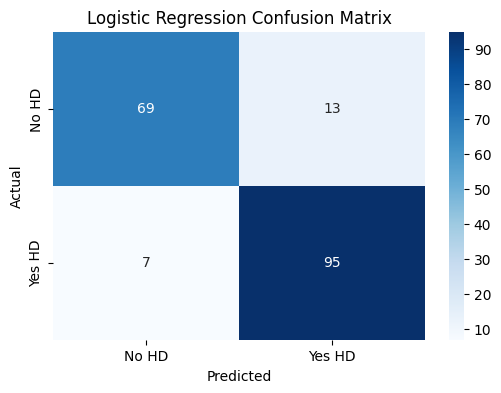

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Logistic Regression model ---
log_reg = LogisticRegression(max_iter=3000, solver="liblinear")
log_reg.fit(X_train, y_train)

# --- Predictions ---
y_pred = log_reg.predict(X_test)

# --- Accuracy Scores ---
train_accuracy = accuracy_score(y_train, log_reg.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# --- Classification Report ---
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No HD", "Yes HD"],
            yticklabels=["No HD", "Yes HD"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
